In [1]:
# Create necessary directory structure for the repository
!mkdir -p data/raw_circuits
!mkdir -p data/optimized_circuits
!mkdir -p results/csv
!mkdir -p results/figures

# Extract the downloaded MQT Bench dataset into the raw_circuits folder
!unzip -q "MQT Benchmark.zip" -d "data/raw_circuits"

In [2]:
# Install required quantum compilation frameworks and parsing utilities
!pip install qiskit qiskit-qasm3-import pytket pytket-qiskit pandas networkx matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.2/234.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB

In [3]:
import os
import time
import pandas as pd
from qiskit import transpile, qasm3, qasm2
from pytket.extensions.qiskit import qiskit_to_tk
from pytket.passes import FullPeepholeOptimise
from pytket.qasm import circuit_to_qasm
from pytket import OpType

# Define paths matching the GitHub repository structure
INPUT_DIR = "data/raw_circuits/MQT Benchmark"
OUTPUT_DIR = "data/optimized_circuits"
CSV_OUT = "results/csv/Phase2_Transpilation_Results.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)
results_data = []

for filename in os.listdir(INPUT_DIR):
  try:
    if filename.endswith(".qasm") and not filename.startswith("._"):
        filepath = os.path.join(INPUT_DIR, filename)
        print(f"Processing: {filename}...")

        # 1. CLEAN DATA COLUMNS
        parts = filename.replace(".qasm", "").split("_")
        algorithm = parts[0].upper()
        qubits = int(parts[-1])

        # 2. LOAD CIRCUIT
        try:
            qc = qasm3.load(filepath)
        except Exception:
            qc = qasm2.load(filepath)

        # 3. IDENTICAL STARTING POINT (The Fix)
        # Decompose custom gates into standard operations so BOTH compilers get the exact same unrolled circuit
        try:
            tket_test = qiskit_to_tk(qc)
        except Exception as e:
            # qc = qc.decompose(reps=2)
             print(f"  -> raw conversion failed ({e}), decomposing for both compilers")
             qc = qc.decompose(reps=10)
             tket_circ = qiskit_to_tk(qc)

        # 4. QISKIT OPTIMIZATION (Level 2)
        start_time_qiskit = time.perf_counter()
        qiskit_transpiled = transpile(qc, basis_gates=['u1', 'u2', 'u3', 'cx'], optimization_level=2)
        qiskit_time = time.perf_counter() - start_time_qiskit

        qiskit_depth = qiskit_transpiled.depth()
        qiskit_2q_gates = qiskit_transpiled.count_ops().get('cx', 0)

        # 5. TKET OPTIMIZATION (Level 2 equivalent)
        tket_circ = qiskit_to_tk(qc) # Using the exact same 'qc' as Qiskit

        start_time_tket = time.perf_counter()
        # Enforcing CX as the target 2Q gate to match Qiskit's basis
        FullPeepholeOptimise(target_2qb_gate=OpType.CX).apply(tket_circ)
        tket_time = time.perf_counter() - start_time_tket

        tket_depth = tket_circ.depth()
        tket_2q_gates = tket_circ.n_2qb_gates()


        # 1. Save Qiskit optimized circuit
        qiskit_out_path = os.path.join(OUTPUT_DIR, f"QISKIT_{filename}")
        qasm2.dump(qiskit_transpiled, qiskit_out_path)

        # 2. Save TKET optimized circuit
        tket_out_path = os.path.join(OUTPUT_DIR, f"TKET_{filename}")
        circuit_to_qasm(tket_circ, tket_out_path, maxwidth=1024)
        # ------------------------------------------------------


        # 6. RECORD METRICS
        results_data.append({
            "Algorithm": algorithm,
            "Qubits": qubits,
            "Qiskit_2Q_Gates": qiskit_2q_gates,
            "Qiskit_Depth": qiskit_depth,
            "Qiskit_Time(s)": round(qiskit_time, 4),
            "TKET_2Q_Gates": tket_2q_gates,
            "TKET_Depth": tket_depth,
            "TKET_Time(s)": round(tket_time, 4)
        })

  except Exception as e:
            print(f"SKIPPED {filename} — error: {e}")
            continue

# Export execution summary
df = pd.DataFrame(results_data)
# Sorting by Algorithm and Qubits for cleaner visualization
df = df.sort_values(by=['Algorithm', 'Qubits']).reset_index(drop=True)
# df.to_csv("Phase2_Transpilation_Results_Fixed.csv", index=False)
df.to_csv(CSV_OUT, index=False)
print("\nPhase 2 Complete. Metrics saved to:", CSV_OUT)
display(df)

Processing: randomcircuit_indep_opt0_64.qasm...
  -> raw conversion failed (<Qubit uid=62>), decomposing for both compilers
Processing: randomcircuit_indep_opt0_80.qasm...
  -> raw conversion failed (<Qubit uid=21188>), decomposing for both compilers
Processing: qaoa_indep_opt0_64.qasm...
  -> raw conversion failed (<Qubit uid=54659>), decomposing for both compilers
Processing: qaoa_indep_opt0_80.qasm...
  -> raw conversion failed (<Qubit uid=58837>), decomposing for both compilers
Processing: qft_indep_opt0_16.qasm...
Processing: qft_indep_opt0_96.qasm...
Processing: qft_indep_opt0_80.qasm...
Processing: qaoa_indep_opt0_96.qasm...
  -> raw conversion failed (<Qubit uid=65255>), decomposing for both compilers
Processing: qft_indep_opt0_32.qasm...
Processing: randomcircuit_indep_opt0_96.qasm...
  -> raw conversion failed (CUGate with nonzero phase), decomposing for both compilers
Processing: qft_indep_opt0_64.qasm...
Processing: qaoa_indep_opt0_32.qasm...
  -> raw conversion failed (<Qu

,Algorithm,Qubits,Qiskit_2Q_Gates,Qiskit_Depth,Qiskit_Time(s),TKET_2Q_Gates,TKET_Depth,TKET_Time(s)
0,QAOA,16,228,96,0.0307,228,96,4.6239
1,QAOA,32,884,213,0.1005,884,213,21.4689
2,QAOA,64,3920,483,0.1207,3920,483,92.0129
3,QAOA,80,6096,573,0.8824,6096,573,140.1273
4,QAOA,96,8940,735,0.2703,8940,735,203.2844
5,QFT,16,238,118,0.0271,240,104,4.8593
6,QFT,32,686,246,0.0315,962,216,22.7522
7,QFT,64,1582,502,0.0592,2626,440,77.0490
8,QFT,80,2030,630,0.0688,3458,552,84.9599
9,QFT,96,2478,758,0.0857,4290,664,105.7379


In [4]:
import pandas as pd

# df = pd.read_csv("Phase2_Transpilation_Results.csv")
df = pd.read_csv("results/csv/Phase2_Transpilation_Results.csv")
print(df.head())
print("---")
print(df.describe())
print("---")
# Calculate differences
df['Depth_Diff (Qiskit - TKET)'] = df['Qiskit_Depth'] - df['TKET_Depth']
df['2Q_Gates_Diff (Qiskit - TKET)'] = df['Qiskit_2Q_Gates'] - df['TKET_2Q_Gates']
print(df)

  Algorithm  Qubits  Qiskit_2Q_Gates  Qiskit_Depth  Qiskit_Time(s)  \
0      QAOA      16              228            96          0.0307   
1      QAOA      32              884           213          0.1005   
2      QAOA      64             3920           483          0.1207   
3      QAOA      80             6096           573          0.8824   
4      QAOA      96             8940           735          0.2703   

   TKET_2Q_Gates  TKET_Depth  TKET_Time(s)  
0            228          96        4.6239  
1            884         213       21.4689  
2           3920         483       92.0129  
3           6096         573      140.1273  
4           8940         735      203.2844  
---
          Qubits  Qiskit_2Q_Gates  Qiskit_Depth  Qiskit_Time(s)  \
count  15.000000        15.000000     15.000000       15.000000   
mean   57.600000      6903.600000   1057.666667        0.348147   
std    30.717143      9829.577602   1221.256301        0.494701   
min    16.000000       228.000000    

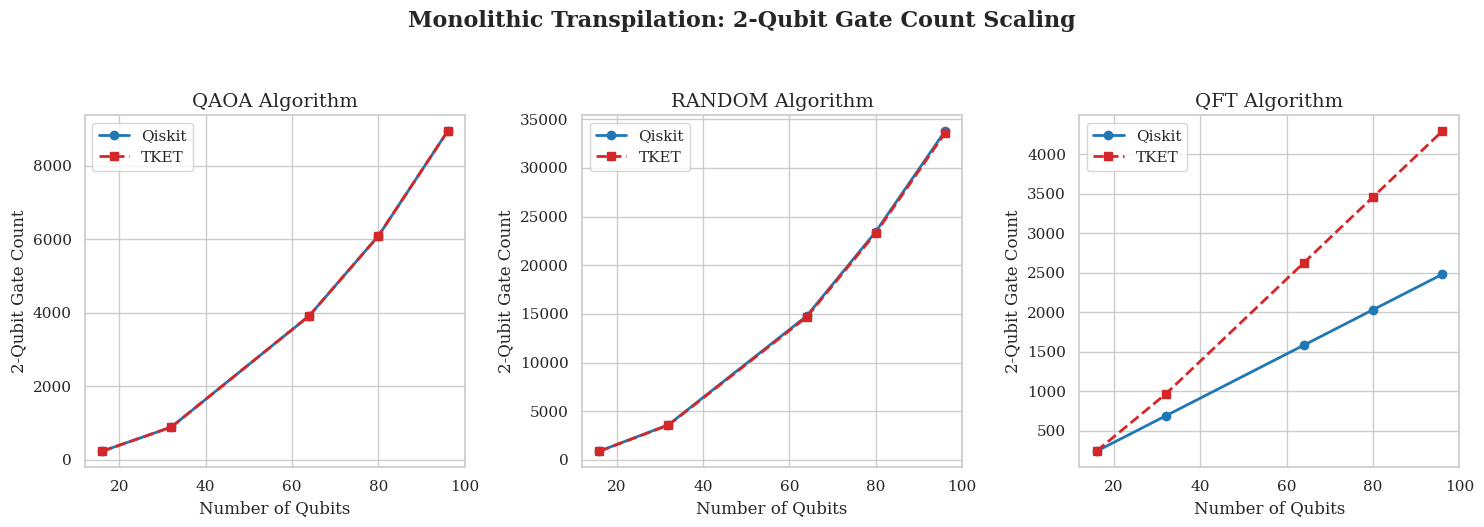

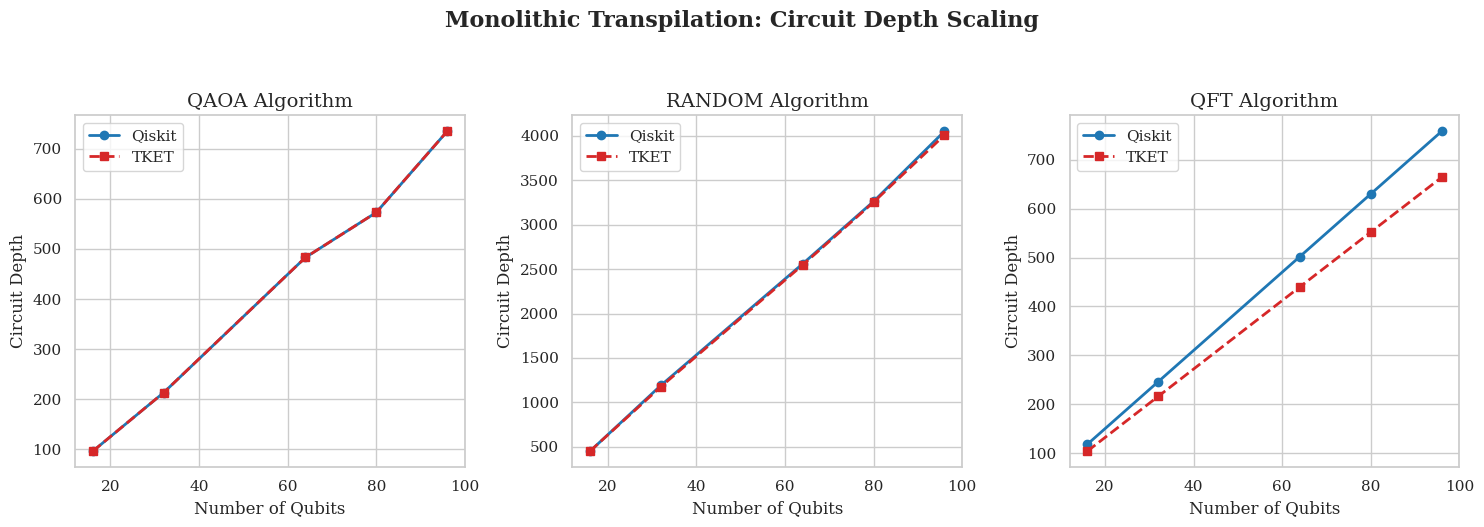

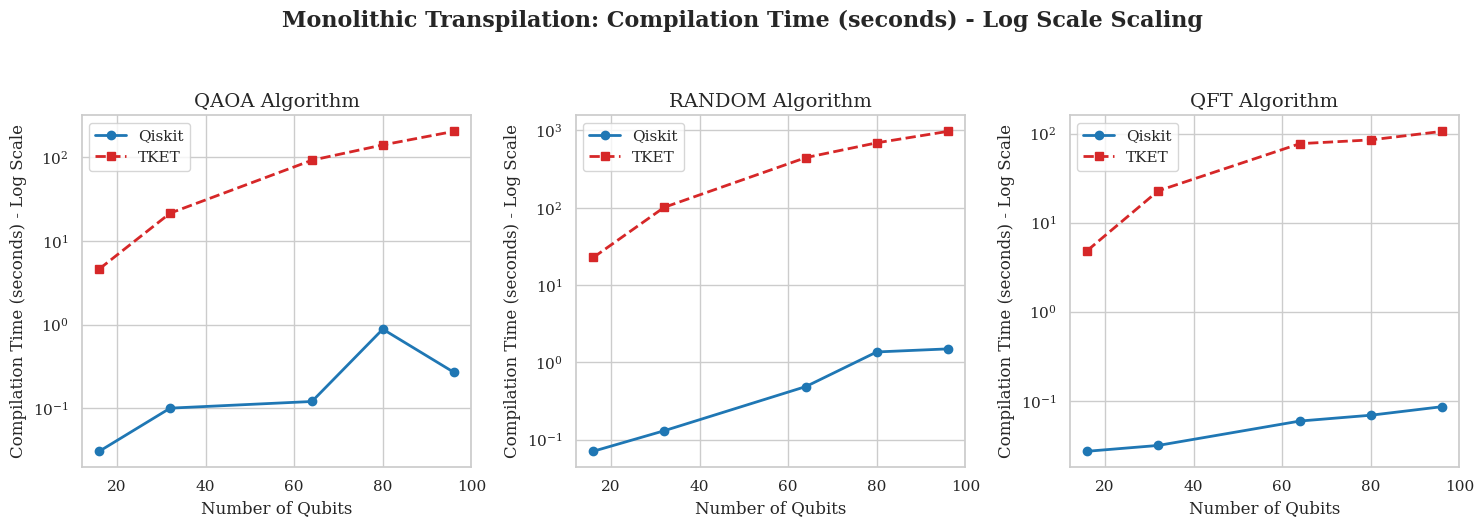

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("results/csv/Phase2_Transpilation_Results.csv")
df['Algorithm'] = df['Algorithm'].replace('RANDOMCIRCUIT', 'RANDOM')

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif', 'axes.titlesize': 14})
algos = ['QAOA', 'RANDOM', 'QFT']
colors = {'Qiskit': '#1f77b4', 'TKET': '#d62728'} # Blue and Red for high contrast

# Helper function to plot
def plot_metric(metric_qiskit, metric_tket, ylabel, filename, log_scale=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Monolithic Transpilation: {ylabel} Scaling', fontsize=16, fontweight='bold', y=1.05)

    for i, algo in enumerate(algos):
        subset = df[df['Algorithm'] == algo]
        axes[i].plot(subset['Qubits'], subset[metric_qiskit], marker='o', color=colors['Qiskit'], label='Qiskit', linewidth=2)
        axes[i].plot(subset['Qubits'], subset[metric_tket], marker='s', linestyle='--', color=colors['TKET'], label='TKET', linewidth=2)
        axes[i].set_title(f'{algo} Algorithm')
        axes[i].set_xlabel('Number of Qubits')
        axes[i].set_ylabel(ylabel)
        if log_scale:
            axes[i].set_yscale('log')
        axes[i].legend()

    plt.tight_layout()
    plt.savefig(f'results/figures/{filename}', dpi=300, bbox_inches='tight')
    plt.show()

# Generate the 3 Figures
plot_metric('Qiskit_2Q_Gates', 'TKET_2Q_Gates', '2-Qubit Gate Count', 'Fig1_Gates.png')
plot_metric('Qiskit_Depth', 'TKET_Depth', 'Circuit Depth', 'Fig2_Depth.png')
plot_metric('Qiskit_Time(s)', 'TKET_Time(s)', 'Compilation Time (seconds) - Log Scale', 'Fig3_Time.png', log_scale=True)

Distributed Quantum Circuit (DQC) Partitioning Simulation

In [10]:
import os
import pandas as pd
import networkx as nx
from networkx.algorithms import community
from qiskit import qasm2

INPUT_DIR = "data/optimized_circuits"
CSV_RAW_OUT = "results/csv/Phase3_DQC_Results_raw.csv"
CSV_PIVOT_OUT = "results/csv/Phase3_DQC_Results.csv"

NUM_QPUS = 4
# Teleportation overhead multipliers simulating distinct networking latency regimes
PENALTY_VALUES = [3, 30, 100]

results_dqc = []

def balanced_four_way_partition(G, all_qubits):
    """Recursive Kernighan-Lin bisection -> 4 near-equal QPU groups.
    KL only swaps nodes between fixed-size groups, so it's naturally balanced – not unconstrained like Louvain."""
    nodes = list(all_qubits)
    if G.number_of_edges() == 0:
        chunk = len(nodes) // NUM_QPUS + 1
        return {q: (i // chunk) for i, q in enumerate(nodes)}

    def safe_bisect(node_set, subgraph):
        node_set = list(node_set)
        if len(node_set) < 2 or subgraph.number_of_edges() == 0:
            half = len(node_set) // 2
            return set(node_set[:half]), set(node_set[half:])
        try:
            return nx.algorithms.community.kernighan_lin_bisection(
                subgraph, weight='weight', seed=42)
        except Exception:
            half = len(node_set) // 2
            return set(node_set[:half]), set(node_set[half:])

    part_a, part_b = safe_bisect(nodes, G)
    qpu01 = safe_bisect(part_a, G.subgraph(part_a))
    qpu23 = safe_bisect(part_b, G.subgraph(part_b))

    qubit_to_qpu = {}
    for qpu_id, qset in enumerate([qpu01[0], qpu01[1], qpu23[0], qpu23[1]]):
        for q in qset:
            qubit_to_qpu[q] = qpu_id
    for q in nodes:
        qubit_to_qpu.setdefault(q, 0)
    return qubit_to_qpu


print("Starting DQC Partitioning Simulation (4-QPU, balanced KL bisection)...\n")

for filename in os.listdir(INPUT_DIR):
    if not filename.endswith(".qasm"):
        continue
    filepath = os.path.join(INPUT_DIR, filename)
    parts = filename.replace(".qasm", "").split("_")
    compiler = parts[0].upper()
    algorithm = parts[1].upper()
    qubits = int(parts[-1])

    try:
        qc = qasm2.load(filepath)
    except Exception as e:
        print(f"SKIPPED {filename}: {e}")
        continue

    # Construct interaction graph: Nodes = Qubits, Edges = Interacting 2-Qubit Gates
    G = nx.Graph()
    G.add_nodes_from(range(qubits))
    total_2q_gates = 0
    original_depth = qc.depth()

    for instruction in qc.data:
        if len(instruction.qubits) == 2:
            q1 = qc.find_bit(instruction.qubits[0]).index
            q2 = qc.find_bit(instruction.qubits[1]).index
            if G.has_edge(q1, q2):
                G[q1][q2]['weight'] += 1
            else:
                G.add_edge(q1, q2, weight=1)
            total_2q_gates += 1

    qubit_to_qpu = balanced_four_way_partition(G, range(qubits))
    qpu_sizes = pd.Series(qubit_to_qpu).value_counts().to_dict()

    # Calculate cross-QPU interactions (E-bit cost)
    ebit_cost = 0
    for instruction in qc.data:
        if len(instruction.qubits) == 2:
            q1 = qc.find_bit(instruction.qubits[0]).index
            q2 = qc.find_bit(instruction.qubits[1]).index
            if qubit_to_qpu.get(q1, 0) != qubit_to_qpu.get(q2, 0):
                ebit_cost += 1

    row = {
        "Algorithm": algorithm,
        "Qubits": qubits,
        "Compiler": compiler,
        "Original_2Q_Gates": total_2q_gates,
        "Original_Depth": original_depth,
        "E-Bit_Cost": ebit_cost,
        "QPU_Sizes": str(qpu_sizes),
    }
    for p in PENALTY_VALUES:
        row[f"Distributed_Depth_p{p}"] = original_depth + (ebit_cost * p)

    results_dqc.append(row)
    print(f"Done: {filename}  (e-bits={ebit_cost}, QPU sizes={qpu_sizes})")

# Export RAW data
df_dqc = pd.DataFrame(results_dqc)
df_dqc.to_csv(CSV_RAW_OUT, index=False)

# Export PIVOT data for side-by-side analysis
pivot_df = df_dqc.pivot_table(
    index=['Algorithm', 'Qubits'], columns='Compiler',
    values=['E-Bit_Cost'] + [f"Distributed_Depth_p{p}" for p in PENALTY_VALUES]
).reset_index()
pivot_df.columns = ['_'.join(col).strip('_') for col in pivot_df.columns.values]
pivot_df = pivot_df.sort_values(by=['Algorithm', 'Qubits'])
pivot_df.to_csv(CSV_PIVOT_OUT, index=False)

print("Phase 3 Complete. Metrics saved to:", CSV_PIVOT_OUT)
display(pivot_df)

Starting DQC Partitioning Simulation (4-QPU, balanced KL bisection)...

Done: QISKIT_qaoa_indep_opt0_80.qasm  (e-bits=3996, QPU sizes={0: 20, 1: 20, 2: 20, 3: 20})
Done: TKET_qaoa_indep_opt0_64.qasm  (e-bits=2596, QPU sizes={0: 16, 1: 16, 2: 16, 3: 16})
Done: QISKIT_qaoa_indep_opt0_64.qasm  (e-bits=2596, QPU sizes={0: 16, 1: 16, 2: 16, 3: 16})
Done: QISKIT_randomcircuit_indep_opt0_64.qasm  (e-bits=10312, QPU sizes={0: 16, 1: 16, 2: 16, 3: 16})
Done: TKET_randomcircuit_indep_opt0_64.qasm  (e-bits=10236, QPU sizes={0: 16, 1: 16, 2: 16, 3: 16})
Done: QISKIT_qft_indep_opt0_96.qasm  (e-bits=630, QPU sizes={0: 24, 1: 24, 2: 24, 3: 24})
Done: QISKIT_qft_indep_opt0_32.qasm  (e-bits=462, QPU sizes={0: 8, 1: 8, 2: 8, 3: 8})
Done: TKET_qaoa_indep_opt0_32.qasm  (e-bits=568, QPU sizes={0: 8, 1: 8, 2: 8, 3: 8})
Done: TKET_qaoa_indep_opt0_96.qasm  (e-bits=5984, QPU sizes={0: 24, 1: 24, 2: 24, 3: 24})
Done: QISKIT_qft_indep_opt0_16.qasm  (e-bits=190, QPU sizes={0: 4, 1: 4, 2: 4, 3: 4})
Done: TKET_qft_

,Algorithm,Qubits,Distributed_Depth_p100_QISKIT,Distributed_Depth_p100_TKET,Distributed_Depth_p3_QISKIT,Distributed_Depth_p3_TKET,Distributed_Depth_p30_QISKIT,Distributed_Depth_p30_TKET,E-Bit_Cost_QISKIT,E-Bit_Cost_TKET
0,QAOA,16,14096.0,14096.0,516.0,516.0,4296.0,4296.0,140.0,140.0
1,QAOA,32,57013.0,57013.0,1917.0,1917.0,17253.0,17253.0,568.0,568.0
2,QAOA,64,260083.0,260083.0,8271.0,8271.0,78363.0,78363.0,2596.0,2596.0
3,QAOA,80,400173.0,400173.0,12561.0,12561.0,120453.0,120453.0,3996.0,3996.0
4,QAOA,96,599135.0,599135.0,18687.0,18687.0,180255.0,180255.0,5984.0,5984.0
5,QFT,16,19118.0,19304.0,688.0,680.0,5818.0,5864.0,190.0,192.0
6,QFT,32,46446.0,74016.0,1632.0,2430.0,14106.0,22356.0,462.0,738.0
7,QFT,64,63502.0,167040.0,2392.0,5438.0,19402.0,50420.0,630.0,1666.0
8,QFT,80,63630.0,194352.0,2520.0,6366.0,19530.0,58692.0,630.0,1938.0
9,QFT,96,63758.0,208864.0,2648.0,6910.0,19658.0,63124.0,630.0,2082.0


Generate Distributed Architecture Performance Charts

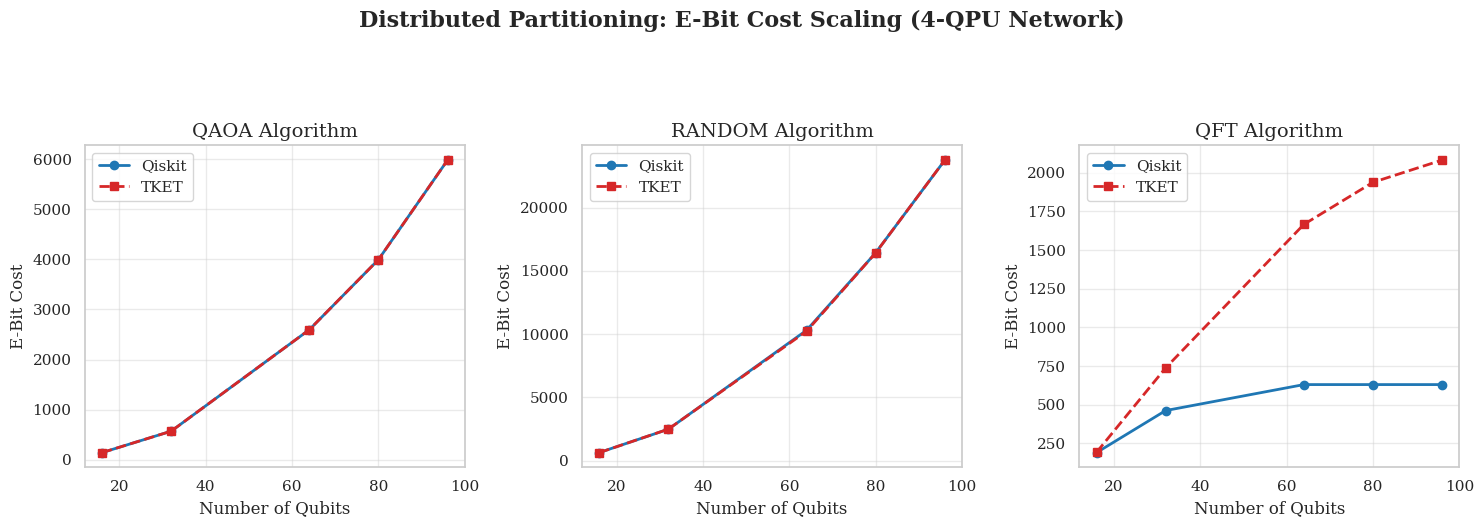

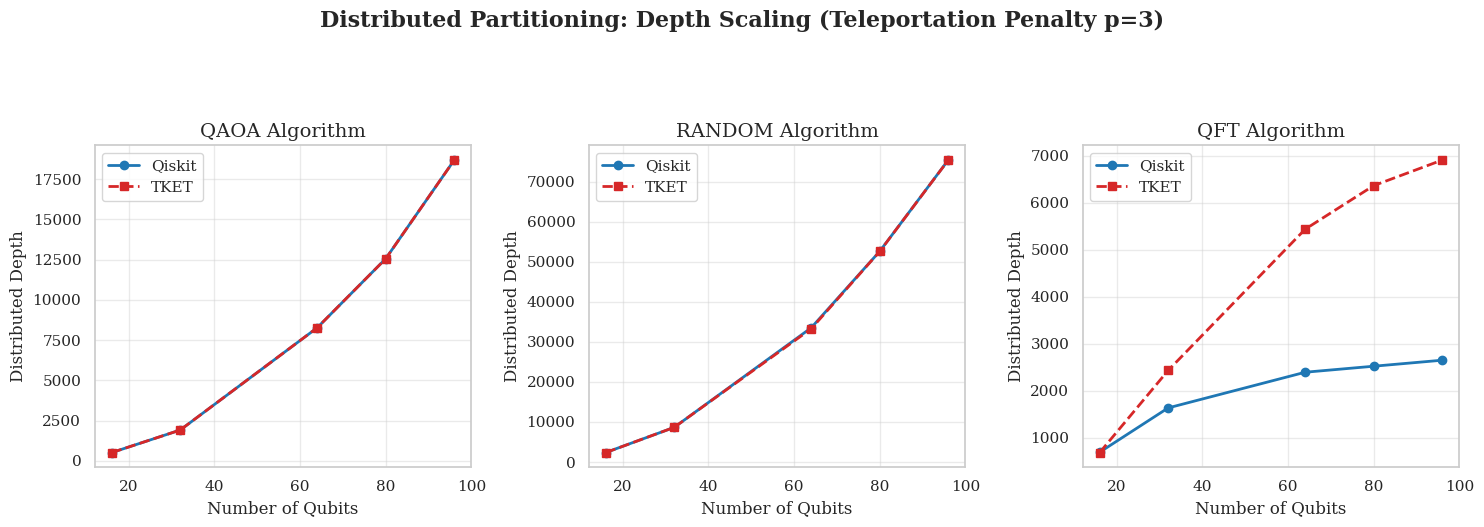

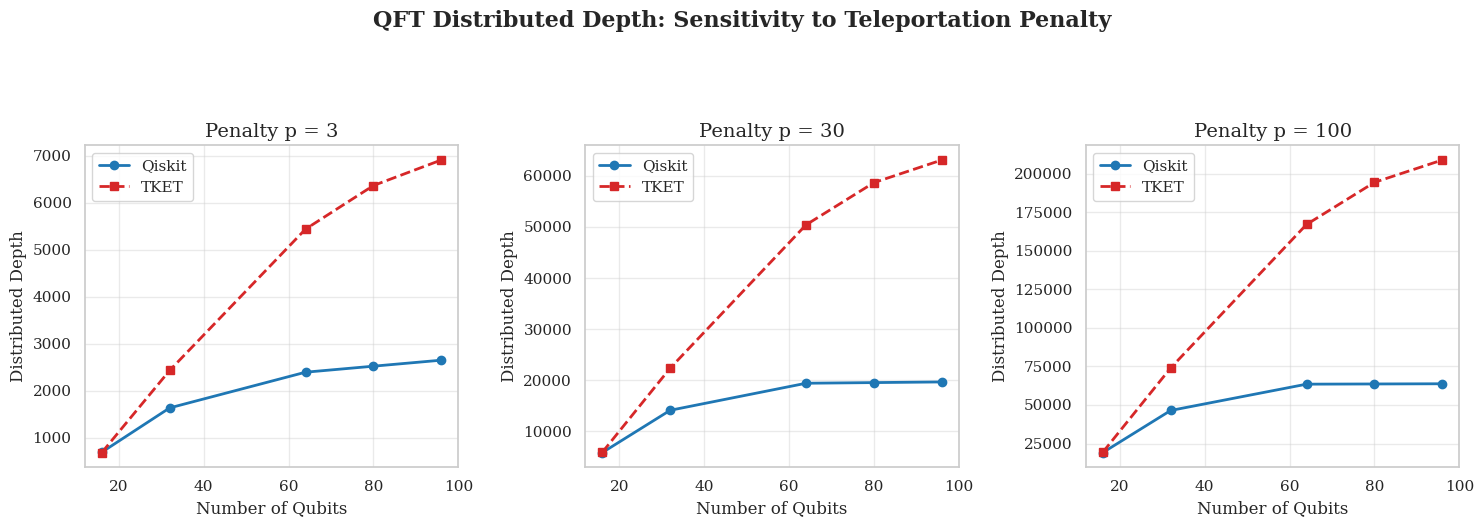

Saved: Fig4_Ebits.png, Fig5_Depth_p3.png, Fig6_QFT_Sensitivity.png


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.titlesize': 14
})

df = pd.read_csv("results/csv/Phase3_DQC_Results_raw.csv")

algorithms = ["QAOA", "RANDOMCIRCUIT", "QFT"]
titles = {"QAOA": "QAOA Algorithm", "RANDOMCIRCUIT": "RANDOM Algorithm", "QFT": "QFT Algorithm"}

def plot_metric(metric_col, ylabel, title, filename, logscale=False):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
    for ax, algo in zip(axes, algorithms):
        sub = df[df["Algorithm"] == algo].sort_values("Qubits")
        for compiler, color, marker, ls in [("QISKIT", "tab:blue", "o", "-"),
                                             ("TKET", "tab:red", "s", "--")]:
            d = sub[sub["Compiler"] == compiler]
            ax.plot(d["Qubits"], d[metric_col], marker=marker, linestyle=ls,
                     color=color, label="Qiskit" if compiler == "QISKIT" else "TKET", linewidth=2)
        ax.set_title(titles[algo])
        ax.set_xlabel("Number of Qubits")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.4)
        ax.legend()
        if logscale:
            ax.set_yscale("log")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(f'results/figures/{filename}', dpi=300, bbox_inches="tight")
    plt.show()

# Figure 4: E-bit cost scaling
plot_metric("E-Bit_Cost", "E-Bit Cost",
            "Distributed Partitioning: E-Bit Cost Scaling (4-QPU Network)",
            "Fig4_Ebits.png")

# Figure 5: Distributed depth (headline penalty p=3)
plot_metric("Distributed_Depth_p3", "Distributed Depth",
            "Distributed Partitioning: Depth Scaling (Teleportation Penalty p=3)",
            "Fig5_Depth_p3.png")

# Figure 6: QFT sensitivity check across all 3 penalty values
qft = df[df["Algorithm"] == "QFT"].sort_values("Qubits")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("QFT Distributed Depth: Sensitivity to Teleportation Penalty",
             fontsize=16, fontweight="bold", y=1.05)
for ax, p in zip(axes, [3, 30, 100]):
    col = f"Distributed_Depth_p{p}"
    for compiler, color, marker, ls in [("QISKIT", "tab:blue", "o", "-"),
                                         ("TKET", "tab:red", "s", "--")]:
        d = qft[qft["Compiler"] == compiler]
        ax.plot(d["Qubits"], d[col], marker=marker, linestyle=ls, color=color,
                 label="Qiskit" if compiler == "QISKIT" else "TKET", linewidth=2)
    ax.set_title(f"Penalty p = {p}")
    ax.set_xlabel("Number of Qubits")
    ax.set_ylabel("Distributed Depth")
    ax.grid(True, alpha=0.4)
    ax.legend()
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("results/figures/Fig6_QFT_Sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: Fig4_Ebits.png, Fig5_Depth_p3.png, Fig6_QFT_Sensitivity.png")

# from google.colab import files
# files.download("Fig4_Ebits.png")
# files.download("Fig5_Depth_p3.png")
# files.download("Fig6_QFT_Sensitivity.png")

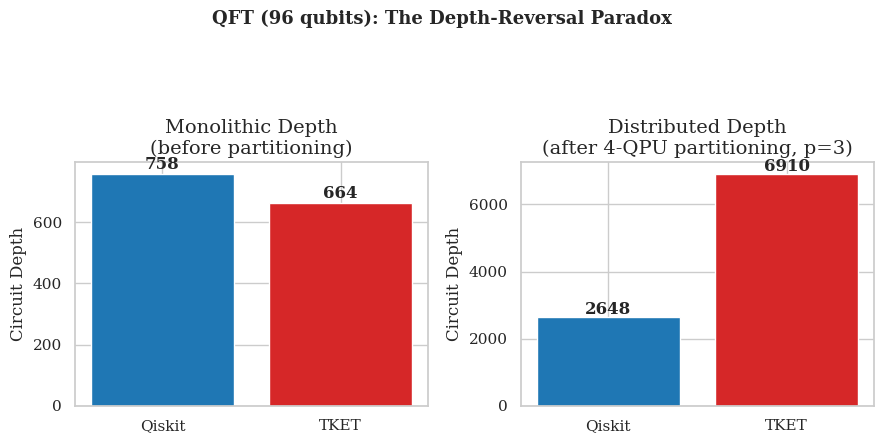

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.titlesize': 14
})

df_phase2 = pd.read_csv("results/csv/Phase2_Transpilation_Results.csv")
df_phase3 = pd.read_csv("results/csv/Phase3_DQC_Results.csv")

# Filter data for the specific climax scenario: QFT at 96 Qubits
qft_96_p2 = df_phase2[(df_phase2['Algorithm'] == 'QFT') & (df_phase2['Qubits'] == 96)].iloc[0]
qft_96_p3 = df_phase3[(df_phase3['Algorithm'] == 'QFT') & (df_phase3['Qubits'] == 96)].iloc[0]

# Extract the exact values dynamically
qiskit_mono_depth = int(qft_96_p2['Qiskit_Depth'])
tket_mono_depth = int(qft_96_p2['TKET_Depth'])

qiskit_dist_depth = int(qft_96_p3['Distributed_Depth_p3_QISKIT'])
tket_dist_depth = int(qft_96_p3['Distributed_Depth_p3_TKET'])

# qiskit_dist_depth = int(qft_96_p3['Distributed_Depth_p3_QISKIT'])
# tket_dist_depth = int(qft_96_p3['Distributed_Depth_p3_TKET'])

# compilers = ["Qiskit", "TKET"]
# monolithic_depth = [758, 664]
# distributed_depth_p3 = [2648, 6910]

compilers = ["Qiskit", "TKET"]
monolithic_depth = [qiskit_mono_depth, tket_mono_depth]
distributed_depth_p3 = [qiskit_dist_depth, tket_dist_depth]

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
colors = ["tab:blue", "tab:red"]

axes[0].bar(compilers, monolithic_depth, color=colors)
axes[0].set_title("Monolithic Depth\n(before partitioning)")
axes[0].set_ylabel("Circuit Depth")
for i, v in enumerate(monolithic_depth):
    axes[0].text(i, v + 15, str(v), ha='center', fontweight='bold')

axes[1].bar(compilers, distributed_depth_p3, color=colors)
axes[1].set_title("Distributed Depth\n(after 4-QPU partitioning, p=3)")
axes[1].set_ylabel("Circuit Depth")
for i, v in enumerate(distributed_depth_p3):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

fig.suptitle("QFT (96 qubits): The Depth-Reversal Paradox", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("results/figures/Fig_Reversal.png", dpi=300, bbox_inches="tight")
plt.show()

# from google.colab import files
# files.download("results/figures/Fig_Reversal.png")
